In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, skew, kurtosis
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("weatherHistory.csv")

In [4]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [6]:
df.shape

(96453, 12)

In [7]:
df.columns.tolist()

['Formatted Date',
 'Summary',
 'Precip Type',
 'Temperature (C)',
 'Apparent Temperature (C)',
 'Humidity',
 'Wind Speed (km/h)',
 'Wind Bearing (degrees)',
 'Visibility (km)',
 'Loud Cover',
 'Pressure (millibars)',
 'Daily Summary']

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [10]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [11]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [12]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '').str.replace('-', '_')

In [13]:
if 'Formatted_Date' in df.columns:
    df['Formatted_Date'] = pd.to_datetime(df['Formatted_Date'], utc=True, errors='coerce')
else:
    df['Formatted_Date'] = pd.to_datetime(df.iloc[:,0], utc=True, errors='coerce')

In [14]:
df.drop_duplicates(inplace=True)
df.dropna(subset=['Formatted_Date'], inplace=True)
df.sort_values(by='Formatted_Date', inplace=True)
df.set_index('Formatted_Date', inplace=True)

In [15]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='ignore')

In [16]:
df.shape

(96429, 11)

In [17]:
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['Hour'] = df.index.hour

def month_to_season(m):
    if m in [12,1,2]: return 'Winter'
    elif m in [3,4,5]: return 'Spring'
    elif m in [6,7,8]: return 'Summer'
    else: return 'Fall'

df['Season'] = df['Month'].apply(month_to_season)

In [18]:
sns.set(style="whitegrid")

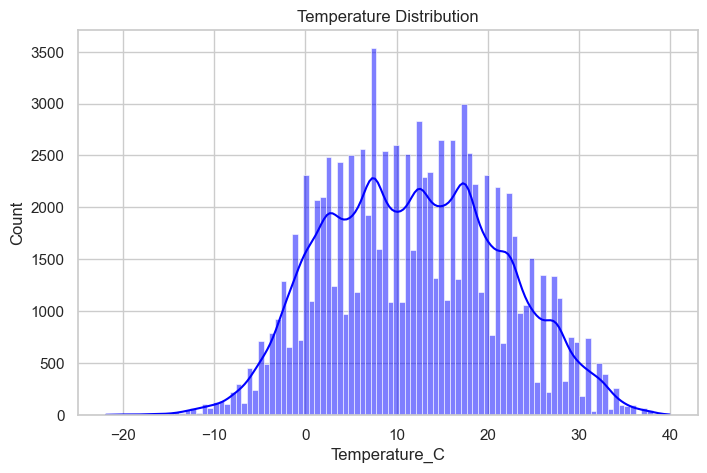

In [37]:
# Temperature Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Temperature_C'], kde=True, color='blue')
plt.title("Temperature Distribution")
plt.show()

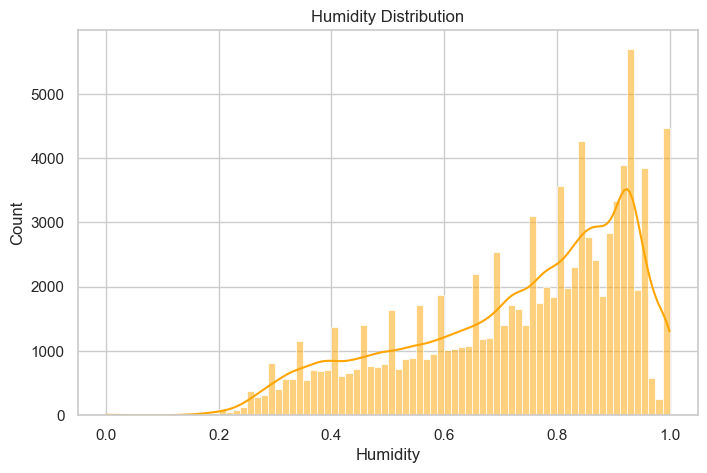

In [20]:
# Humidity Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Humidity'], kde=True, color='orange')
plt.title("Humidity Distribution")
plt.show()

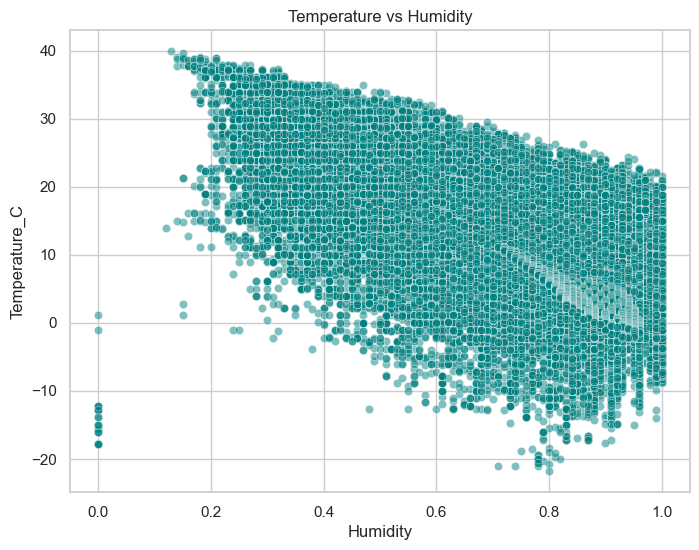

In [40]:
# Temperature vs Humidity
plt.figure(figsize=(8,6))
sns.scatterplot(x='Humidity', y='Temperature_C', data=df, alpha=0.5,color='teal')
plt.title("Temperature vs Humidity")
plt.show()

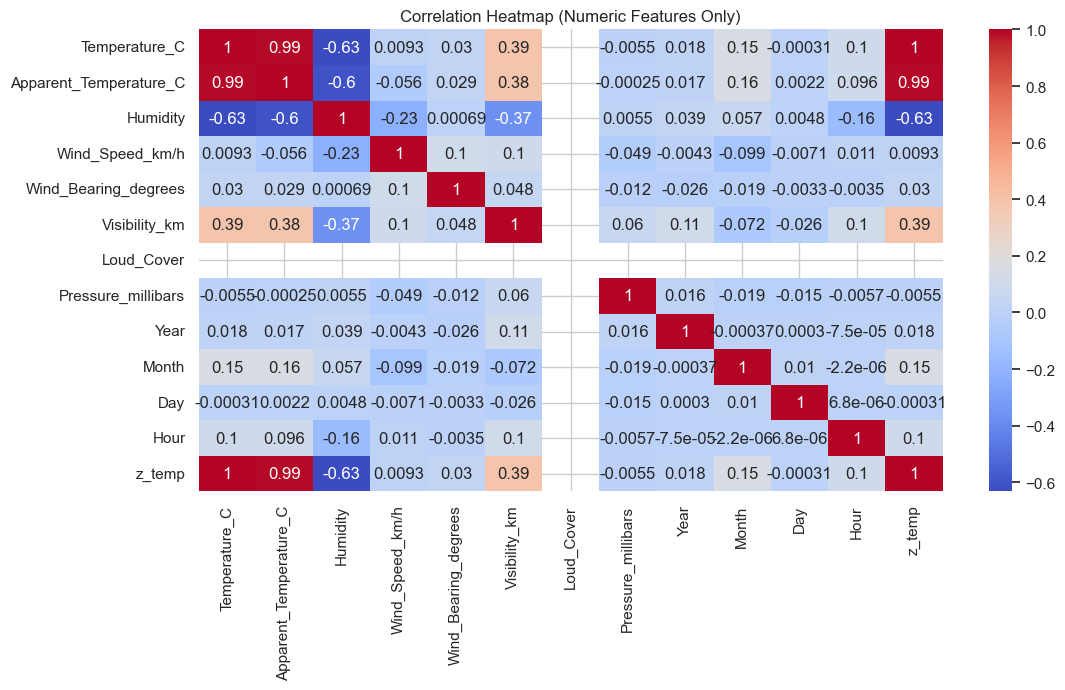

In [35]:
# Correlation Heatmap
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Then create the correlation heatmap
plt.figure(figsize=(12,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()


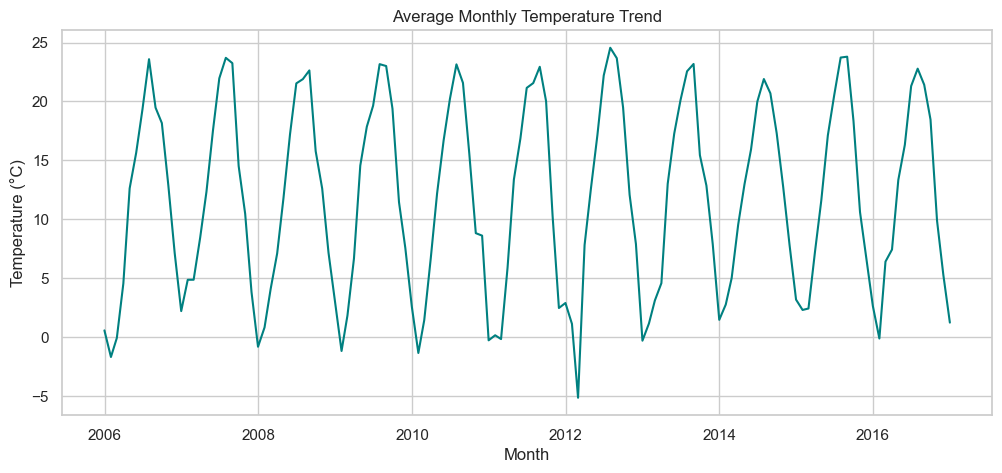

In [23]:
monthly_temp = df['Temperature_C'].resample('M').mean()
plt.figure(figsize=(12,5))
plt.plot(monthly_temp, color='teal')
plt.title("Average Monthly Temperature Trend")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

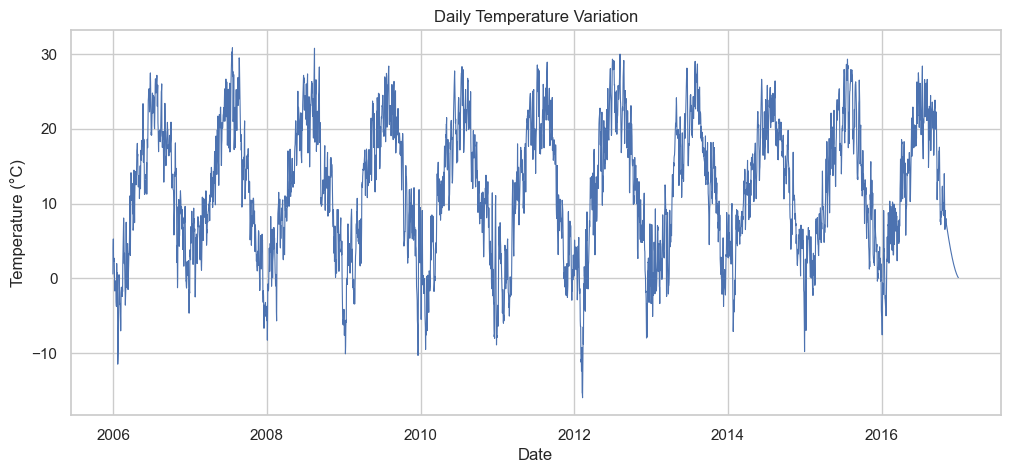

In [24]:
# Daily Variation
daily_temp = df['Temperature_C'].resample('D').mean()
plt.figure(figsize=(12,5))
plt.plot(daily_temp, linewidth=0.8)
plt.title("Daily Temperature Variation")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

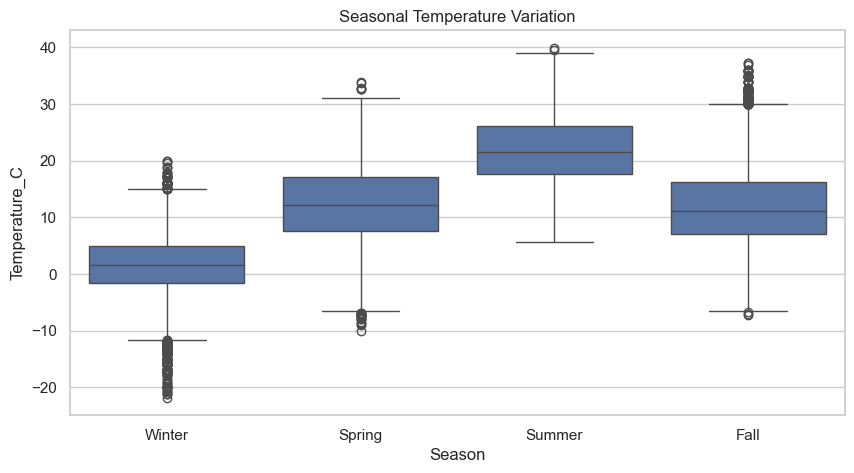

In [25]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Season', y='Temperature_C', data=df)
plt.title("Seasonal Temperature Variation")
plt.show()

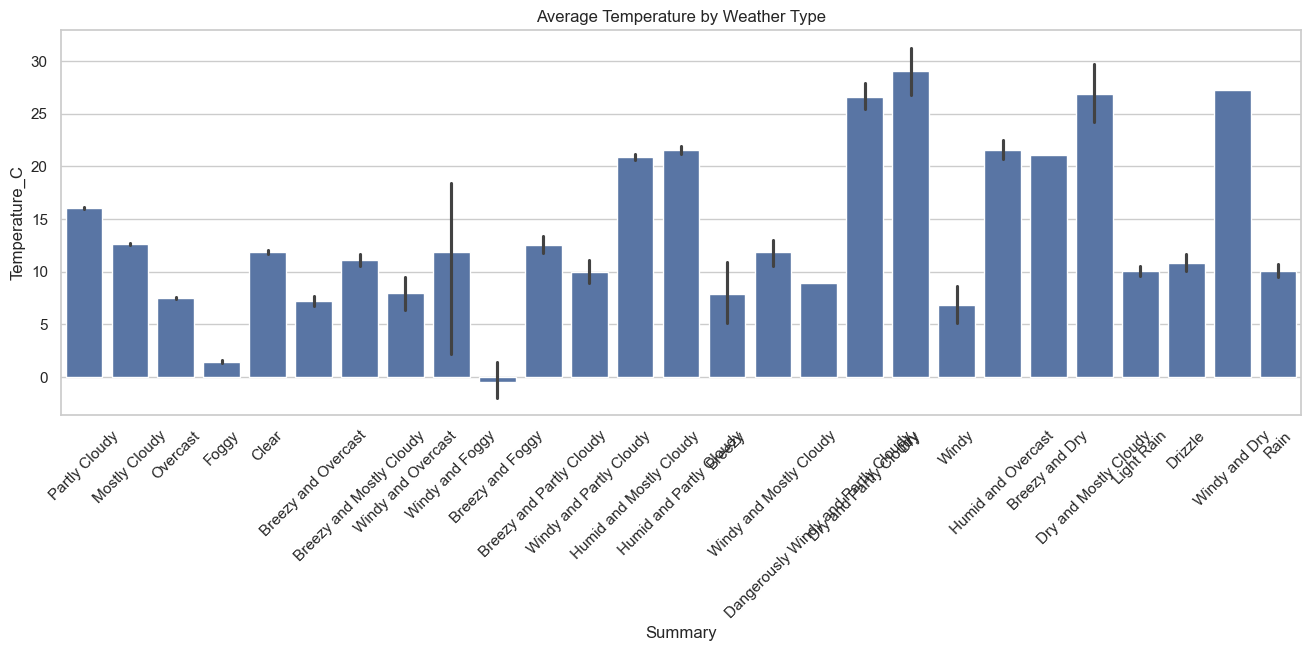

In [27]:
if 'Summary' in df.columns:
    plt.figure(figsize=(16,5))
    sns.barplot(x='Summary', y='Temperature_C', data=df)
    plt.xticks(rotation=45)
    plt.title("Average Temperature by Weather Type")
    plt.show()

In [28]:
df['z_temp'] = zscore(df['Temperature_C'])
outliers = df[np.abs(df['z_temp']) > 3]
print("Outliers Detected:", outliers.shape[0])

Outliers Detected: 39


In [29]:
print("\nSkewness of Temperature:", round(skew(df['Temperature_C']),2))
print("Kurtosis of Temperature:", round(kurtosis(df['Temperature_C']),2))
print("Correlation with Humidity:", df['Temperature_C'].corr(df['Humidity']))


Skewness of Temperature: 0.09
Kurtosis of Temperature: -0.57
Correlation with Humidity: -0.6323310338509759


In [32]:
df.columns

Index(['Summary', 'Precip_Type', 'Temperature_C', 'Apparent_Temperature_C',
       'Humidity', 'Wind_Speed_km/h', 'Wind_Bearing_degrees', 'Visibility_km',
       'Loud_Cover', 'Pressure_millibars', 'Daily_Summary', 'Year', 'Month',
       'Day', 'Hour', 'Season', 'z_temp'],
      dtype='object')

In [33]:
X = df[['Humidity', 'Wind_Speed_km/h']].dropna()
y = df.loc[X.index, 'Temperature_C']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("\n--- Linear Regression Model ---")
print("R² Score:", round(r2_score(y_test, y_pred), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))
print("Coefficients:", dict(zip(X.columns, model.coef_)))



--- Linear Regression Model ---
R² Score: 0.416
RMSE: 7.291
Coefficients: {'Humidity': np.float64(-32.475538640289436), 'Wind_Speed_km/h': np.float64(-0.19367060866646632)}
